# Titanic: разведочный анализ данных (EDA) для логистической регрессии

**Задача:** предсказать, выжил пассажир "Титаника" или нет (`Survived`: 0/1) —
это задача **бинарной классификации**, для которой мы будем использовать
логистическую регрессию.

**Что в этом ноутбуке:** только разведочный анализ данных (EDA) и обоснование
решений по предобработке и инженерии признаков. Сам код предобработки живёт в
[`src/titanic_preprocessing.py`](../src/titanic_preprocessing.py) и переиспользуется
отсюда и из [`scripts/train_titanic.py`](../scripts/train_titanic.py) — то есть
то, что мы здесь увидим и объясним, **буквально то же самое**, что использует
финальный пайплайн обучения (никакого дублирования и расхождения логики).

**Что НЕ в этом ноутбуке:** обучение модели, подбор гиперпараметров, метрики
качества — это в `scripts/train_titanic.py`. Теория логистической регрессии
(сигмоида, log loss, метрики классификации) — в
[`tutorials/logisticregression.ipynb`](../tutorials/logisticregression.ipynb).

In [1]:
import os
from pathlib import Path

# Jupyter запускает ноутбук с cwd=notebooks/, а все пути в src/ (data/..., models/...)
# заданы относительно корня репозитория — поднимаемся туда один раз.
if not Path("pyproject.toml").exists() and Path("../pyproject.toml").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.titanic_preprocessing import extract_title, load_raw
from utils.plotting import (
    plot_categorical_vs_target,
    plot_correlation_heatmap,
    plot_missing_values,
    set_style,
)

set_style()
pd.set_option("display.max_columns", 20)

train, test = load_raw()
print("train:", train.shape, " test:", test.shape)
train.head()

train: (891, 12)  test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Общий обзор

11 признаков + целевая переменная `Survived`. Колонки:

- `Pclass` — класс каюты (1/2/3), косвенно отражает социально-экономический статус;
- `Sex`, `Age` — пол и возраст;
- `SibSp`, `Parch` — число братьев/сестёр/супругов и родителей/детей на борту;
- `Fare` — стоимость билета;
- `Cabin`, `Embarked` — каюта и порт посадки;
- `Name`, `Ticket` — текстовые поля, из которых можно достать скрытые признаки
  (например, титул из имени).

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Целевая переменная

Прежде чем что-либо моделировать, полезно посмотреть на баланс классов: если
он сильно смещён, accuracy становится обманчивой метрикой (модель, всегда
предсказывающая класс большинства, будет иметь высокую accuracy, ничего не
объясняя).

In [3]:
survival_rate = train["Survived"].mean()
print(f"Доля выживших: {survival_rate:.1%}")
print(f"Accuracy модели, всегда предсказывающей 0 (никто не выжил): {1 - survival_rate:.1%}")

Доля выживших: 38.4%
Accuracy модели, всегда предсказывающей 0 (никто не выжил): 61.6%


Классы не идеально сбалансированы (61%/39%), но и не критично — accuracy
"наивной" модели, предсказывающей всегда 0, составит ~62%. Это и есть та
планка, ниже которой опускаться нельзя: **любая обученная модель должна
уверенно превосходить константный прогноз**. Держим это число в голове —
в `scripts/train_titanic.py` наш baseline logistic regression даст заметно
больше.

## 3. Пропущенные значения

`Cabin` пропущен почти у 3/4 пассажиров, `Age` — примерно у 20%, `Embarked` —
всего у двух строк. Стратегия обработки пропусков зависит от их смысла и доли:

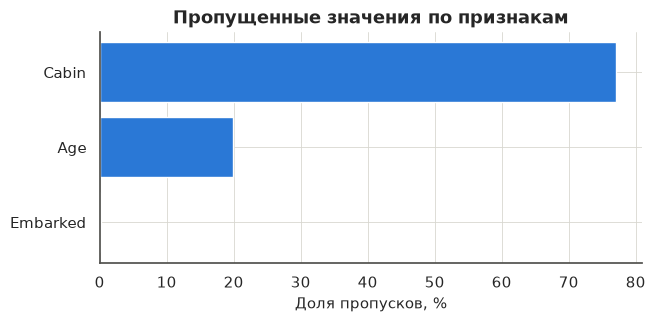

In [4]:
plot_missing_values(train)
plt.show()

Решения (реализованы в `src/titanic_preprocessing.py`):

- **`Cabin`** — пропуск, скорее всего, означает "нет данных о каюте" (а не
  "нет каюты" — билет всё равно предполагал место). Вместо того чтобы просто
  выбросить признак, извлекаем первую букву (палубу) там, где она есть, и
  помечаем пропуски как отдельную категорию `"Unknown"` — сам факт отсутствия
  данных о каюте может быть информативным (например, коррелировать с классом
  билета).
- **`Age`** — пропуски заполняем не общей медианой, а медианой **внутри
  группы по титулу** (`Mr`/`Mrs`/`Miss`/`Master`/`Rare`) — у `Master` (мальчики)
  медианный возраст сильно ниже, чем у `Mr`, и наивная общая медиана исказила
  бы именно самую предсказательную часть выборки (детей).
- **`Embarked`** — всего 2 пропуска, заполняем модой (самый частый порт).

## 4. Пол и класс каюты — самые сильные сигналы

Историческое правило "женщины и дети — первыми" должно явно проявиться в
данных.

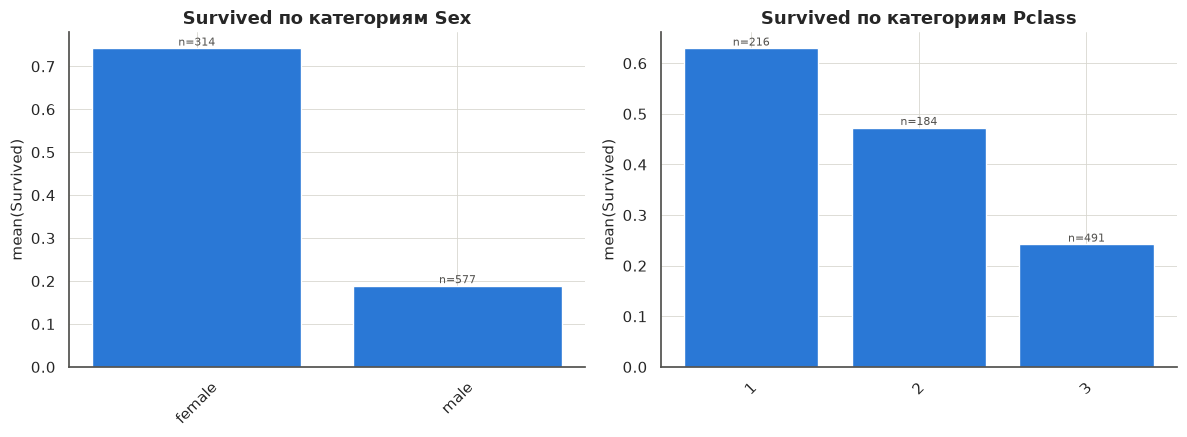

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_categorical_vs_target(train, "Sex", "Survived", ax=axes[0])
plot_categorical_vs_target(train, "Pclass", "Survived", ax=axes[1])
fig.tight_layout()
plt.show()

In [6]:
pd.crosstab(train["Sex"], train["Survived"], normalize="index").round(3)

Survived,0,1
Sex,,
female,0.258,0.742
male,0.811,0.189


Оба признака — сильнейшие предикторы: женщины выживают примерно в 3.5 раза
чаще мужчин (74% против 19%), а пассажиры 1 класса — почти в 2.5 раза чаще
пассажиров 3 класса. Это ожидаемо и по историческим причинам (порядок посадки
в шлюпки), и по косвенным (1 класс располагался ближе к палубе со шлюпками).
`Sex` и `Pclass` точно попадут в модель.

## 5. Возраст

Возраст — величина непрерывная, интересно посмотреть не только на общее
распределение, но и на распределение отдельно среди выживших и погибших.

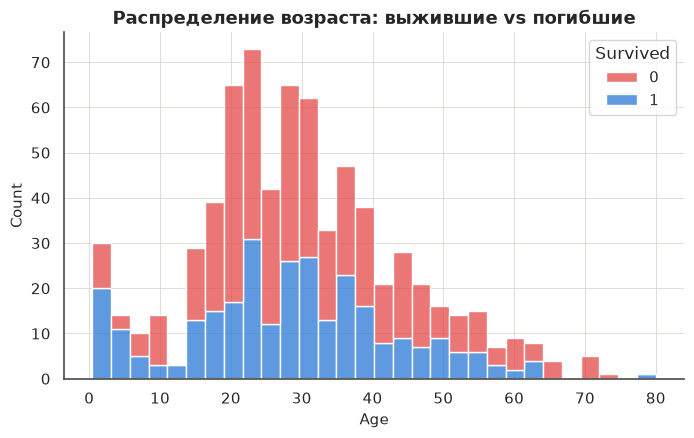

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=train, x="Age", hue="Survived", multiple="stack",
             bins=30, palette=["#e34948", "#2a78d6"], ax=ax)
ax.set_title("Распределение возраста: выжившие vs погибшие")
plt.show()

Заметен всплеск выживаемости у самых маленьких детей (до ~5 лет) — снова
"women and children first". У взрослых заметной зависимости от возраста
на глаз не видно, но небольшой эффект может остаться и будет пойман моделью
через коэффициент при `Age`.

## 6. Fare — стоимость билета

`Fare` тесно связан с `Pclass`, но несёт дополнительную информацию (внутри
одного класса цены варьируются). Как и большинство "денежных" величин,
`Fare` сильно скошен вправо — единицы пассажиров купили очень дорогие
билеты, что растягивает распределение.

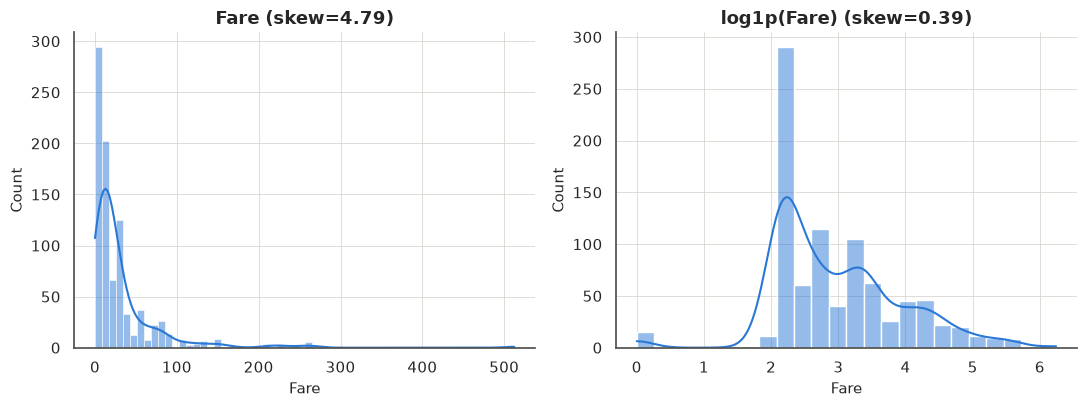

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.histplot(train["Fare"], kde=True, ax=axes[0], color="#2a78d6")
axes[0].set_title(f"Fare (skew={train['Fare'].skew():.2f})")
sns.histplot(np.log1p(train["Fare"]), kde=True, ax=axes[1], color="#2a78d6")
axes[1].set_title(f"log1p(Fare) (skew={np.log1p(train['Fare']).skew():.2f})")
fig.tight_layout()
plt.show()

После `log1p` скошенность падает почти в 10 раз — логистическая регрессия
не требует нормальности признаков так строго, как линейная, но сильно
скошенные величины всё равно дают более стабильные и интерпретируемые
коэффициенты после логарифмирования (выбросы перестают доминировать над
масштабом признака). Поэтому в финальном пайплайне `Fare` идёт в модель
после `log1p`.

## 7. Семья на борту: SibSp, Parch → FamilySize

`SibSp` (братья/сёстры/супруги) и `Parch` (родители/дети) по отдельности —
разреженные признаки с длинным хвостом редких значений. Их сумма даёт более
плотный и интерпретируемый признак `FamilySize`, а также позволяет выделить
`IsAlone` — путешествовал ли пассажир один.

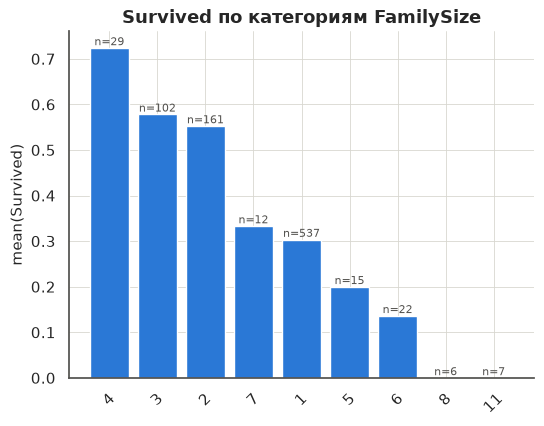

In [9]:
family_df = train.assign(FamilySize=train["SibSp"] + train["Parch"] + 1)
plot_categorical_vs_target(family_df, "FamilySize", "Survived")
plt.show()

Одиночки (`FamilySize=1`) и очень большие семьи (5+) выживают заметно хуже,
чем пассажиры в семьях среднего размера (2-4 человека) — вероятно, одиноким
некому помочь, а большим семьям сложнее держаться вместе при эвакуации.
Зависимость немонотонна, поэтому `FamilySize` как непрерывный числовой
признак — не идеален, но `IsAlone` (бинарный флаг) хорошо ловит худшую
подгруппу. Оба признака идут в модель.

## 8. Скрытый признак в имени: титул

Колонка `Name` выглядит бесполезной для модели напрямую, но в ней зашит
титул (`Mr.`, `Mrs.`, `Miss.`, `Master.`, ...) — прокси для пола, возраста и
социального статуса одновременно.

In [10]:
titles = extract_title(train)
titles.value_counts()

Name
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64

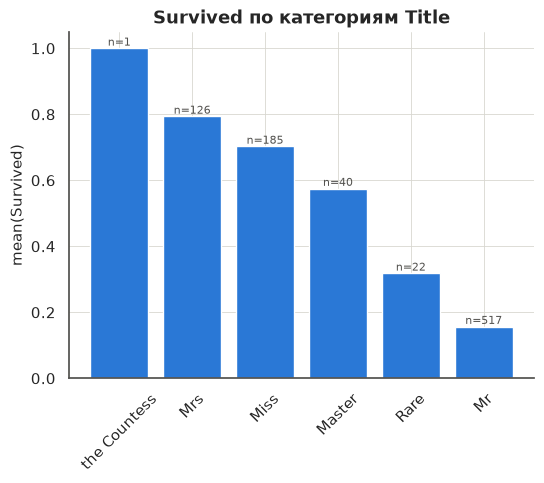

In [11]:
plot_categorical_vs_target(train.assign(Title=titles), "Title", "Survived")
plt.show()

После группировки редких титулов (`Dr`, `Col`, `Major`, ... → `Rare`; `Mlle`,
`Ms` → `Miss`; `Mme` → `Mrs`, см. `TITLE_MAP` в `src/titanic_preprocessing.py`)
получаем 5 компактных групп с чёткой разной выживаемостью — `Title` оказывается
даже информативнее одного `Sex`, потому что заодно кодирует примерный возраст
(`Master` — мальчики) и социальный статус (`Rare` часто означает дворянский
титул или редкую профессию). Именно `Title` мы используем и для группового
заполнения пропусков в `Age` (см. пункт 3).

## 9. Корреляции числовых/кодированных признаков с целевой переменной

Финальный взгляд — на матрицу корреляций уже после кодирования пола в 0/1 и
добавления инженерных признаков, чтобы увидеть силу связи в одном масштабе.

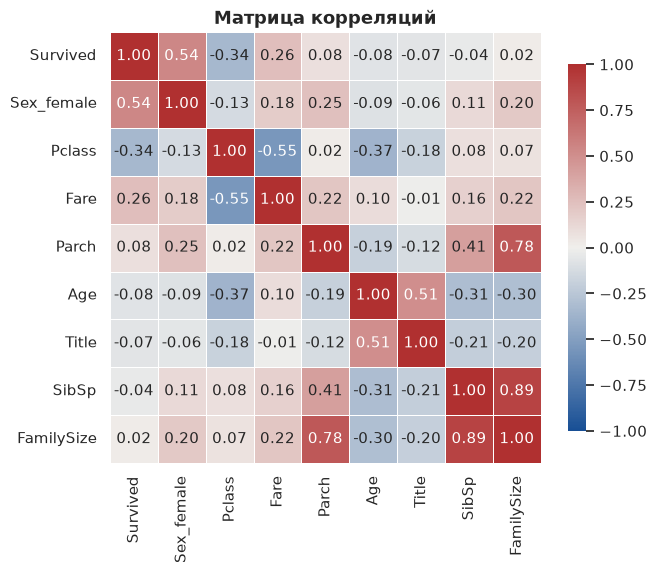

In [12]:
corr_view = train.assign(
    Sex_female=(train["Sex"] == "female").astype(int),
    Title=titles,
    FamilySize=train["SibSp"] + train["Parch"] + 1,
)
corr_view["Title"] = corr_view["Title"].astype("category").cat.codes
plot_correlation_heatmap(corr_view, target="Survived", top_n=8)
plt.show()

## 10. Итог: план предобработки и инженерии признаков

По результатам EDA для финальной модели (`src/titanic_preprocessing.py`,
`build_final_pipeline`) используются:

| Признак | Источник | Обработка |
|---|---|---|
| `Pclass` | как есть | числовой, масштабирование |
| `Sex` | как есть | One-Hot |
| `Age` | инженерный импут | пропуски → медиана по `Title`, масштабирование |
| `Fare` | инженерный | `log1p`, масштабирование |
| `FamilySize` | `SibSp + Parch + 1` | числовой, масштабирование |
| `IsAlone` | `FamilySize == 1` | бинарный |
| `Title` | извлечён из `Name` | One-Hot |
| `Deck` | первая буква `Cabin`, `NaN → "Unknown"` | One-Hot |
| `Embarked` | пропуски → мода | One-Hot |

Baseline-модель (для сравнения) сознательно использует только
`Pclass, Sex, Age, Fare, SibSp, Parch` без какой-либо инженерии — так,
как решил бы задачу студент в первый день знакомства с ML. Насколько
инженерия признаков и корректный `ColumnTransformer` в итоге улучшают
качество — смотрите реальные метрики в `models/titanic/metrics.json`
(воспроизводятся запуском `python scripts/train_titanic.py`) и в
[README.md](../README.md).